From Raw data, generate binarized scRNA-seq

1. Get on an R kernel 
2. Use binarization from Cohen_TCGA_colon_profiles_tuto.Rmd file: Scripts/Profiles/Cohen_TCGA_colon_profiles_tuto.Rmd

Print the raw data format (optional)

In [3]:
#Check the raw data format
raw_data <- read.delim(
  "/Users/alicedecugis/Desktop/hematopoiesis/data/nestorowa_singlecell_raw_data.tsv",
  header = TRUE,
  sep = "\t",
  check.names = FALSE
)

#print out some metrics
dim(raw_data)
head(raw_data[, 1:10])
colnames(raw_data)[1:20]

[1] 4768 1657

,,HSPC_025,HSPC_031,HSPC_037,LT-HSC_001,HSPC_001,HSPC_008,HSPC_014,HSPC_020,HSPC_026
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Clec1b,0.000000,0.000000,0.000000,0.000000,0.000000,1.172368,0.000000,0.000000,0.000000
2,Kdm3a,4.891604,6.877725,0.000000,0.000000,0.000000,8.313856,2.209467,0.000000,1.105106
3,Coro2b,1.426148,0.000000,6.913384,8.178374,9.475577,1.172368,0.000000,0.000000,0.000000
4,8430408G22Rik,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.873639
5,Clec9a,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,Phf6,2.599758,2.423483,2.051659,6.419817,7.733370,7.856124,1.491864,7.260845,8.860815


[1] ""           "HSPC_025"   "HSPC_031"   "HSPC_037"   "LT-HSC_001"
 [6] "HSPC_001"   "HSPC_008"   "HSPC_014"   "HSPC_020"   "HSPC_026"  
[11] "HSPC_038"   "LT-HSC_002" "HSPC_002"   "HSPC_009"   "HSPC_015"  
[16] "HSPC_021"   "HSPC_027"   "HSPC_033"   "LT-HSC_003" "HSPC_003"

Load data and adapt coprrect format

1. Reads the TSV.
2. Uses the first column as gene names.
3. Removes the gene-name column from the data.
4. Transposes the matrix so it becomes cells × genes.
5. Adds the cell IDs as PATIENT_ID.

In [ ]:
#-------------------------------
#Load and transpose the data, add cell IDs to the gene name
#-------------------------------
raw_data <- read.delim(
  "/Users/alicedecugis/Desktop/hematopoiesis/data/nestorowa_singlecell_raw_data.tsv",
  header = TRUE,
  sep = "\t",
  check.names = FALSE
)

# Gene names become row names
rownames(raw_data) <- raw_data[[1]]
raw_data <- raw_data[, -1]

# Transpose: cells × genes
Nestorowa_RNA <- as.data.frame(t(raw_data))

# Add cell IDs
Nestorowa_RNA$PATIENT_ID <- rownames(Nestorowa_RNA)
rownames(Nestorowa_RNA) <- NULL

#check they were added correctly
#str(Nestorowa_RNA)

#check: should have 19 rows
#dim(Nestorowa_RNA)
#Nestorowa_RNA$PATIENT_ID

'data.frame':	1656 obs. of  4769 variables:
 $ Clec1b        : num  0 0 0 0 0 ...
 $ Kdm3a         : num  4.89 6.88 0 0 0 ...
 $ Coro2b        : num  1.43 0 6.91 8.18 9.48 ...
 $ 8430408G22Rik : num  0 0 0 0 0 ...
 $ Clec9a        : num  0 0 0 0 0 0 0 0 0 0 ...
 $ Phf6          : num  2.6 2.42 2.05 6.42 7.73 ...
 $ Usp14         : num  2.95 1.8 8.27 3.45 1.48 ...
 $ Tmem167b      : num  6.36 0 0 2.58 0 ...
 $ Kbtbd7        : num  2.13 0 1.36 2.58 10.05 ...
 $ Rag2          : num  1.426 0 0 0 0.533 ...
 $ Hmgcs1        : num  7.349 0 6.816 8.489 0.533 ...
 $ Adgre1        : num  1.43 0 0 0 0 ...
 $ Zfp947        : num  0 0 0 0 0 ...
 $ Atad2         : num  3.68 3.08 1.36 2.58 1.23 ...
 $ Bhlhb9        : num  5.781 0.699 2.052 8.227 8.974 ...
 $ Vcam1         : num  0 0 1.36 2.58 0 ...
 $ Mns1          : num  3.24 1.52 2.05 2.58 2.56 ...
 $ Tbc1d5        : num  5.91 5.35 2.87 2.58 9.19 ...
 $ Sardh         : num  0 0 0 0 0 0 0 0 0 0 ...
 $ Wdr75         : num  6.63 6.77 8.24 3.99 9.1 ...

Install and load all packages

In [41]:
#install.packages("diptest")
#install.packages("mclust")
#install.packages("moments")
#install.packages("knitr")

# ============================================================
# NESTOROWA SINGLE-CELL RNA BINARIZATION
# ============================================================

library(tidyverse)
library(mclust)
library(diptest)
library(moments)
library(knitr)

In [33]:
# ============================================================
# 1. LOAD AND PREPARE DATA
# ============================================================

raw_data <- read.delim(
  "/Users/alicedecugis/Desktop/hematopoiesis/data/nestorowa_singlecell_raw_data.tsv",
  header = TRUE,
  sep = "\t",
  check.names = FALSE
)

# First column contains gene names
rownames(raw_data) <- raw_data[[1]]
raw_data <- raw_data[, -1]

# Transpose: cells x genes
Nestorowa_RNA <- as.data.frame(t(raw_data))

# Add cell IDs
Nestorowa_RNA$PATIENT_ID <- rownames(Nestorowa_RNA)
rownames(Nestorowa_RNA) <- NULL

# Check
dim(Nestorowa_RNA)
head(Nestorowa_RNA[, 1:19])
head(Nestorowa_RNA$PATIENT_ID)


[1] 1656 4769

,Clec1b,Kdm3a,Coro2b,8430408G22Rik,Clec9a,Phf6,Usp14,Tmem167b,Kbtbd7,Rag2,Hmgcs1,Adgre1,Zfp947,Atad2,Bhlhb9,Vcam1,Mns1,Tbc1d5,Sardh
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.000000,4.891604,1.426148,0,0,2.599758,2.954035,6.357369,2.129140,1.4261482,7.3485436,1.426148,0,3.679309,5.7811774,0.000000,3.238239,5.908210,0
2,0.000000,6.877725,0.000000,0,0,2.423483,1.804914,0.000000,0.000000,0.0000000,0.0000000,0.000000,0,3.084447,0.6991259,0.000000,1.521334,5.354217,0
3,0.000000,0.000000,6.913384,0,0,2.051659,8.265465,0.000000,1.363402,0.0000000,6.8160467,0.000000,0,1.363402,2.0516593,1.363402,2.051659,2.866245,0
4,0.000000,0.000000,8.178374,0,0,6.419817,3.453502,2.579528,2.579528,0.0000000,8.4893491,0.000000,0,2.579528,8.2271173,2.579528,2.579528,2.579528,0
5,0.000000,0.000000,9.475577,0,0,7.733370,1.478900,0.000000,10.045601,0.5329056,0.5329056,0.000000,0,1.226829,8.9738453,0.000000,2.564437,9.193444,0
6,1.172368,8.313856,1.172368,0,0,7.856124,3.091340,0.000000,7.902221,0.0000000,6.5318230,0.000000,0,1.172368,7.3794066,1.172368,1.172368,0.000000,0


[1] "HSPC_025"   "HSPC_031"   "HSPC_037"   "LT-HSC_001" "HSPC_001"  
[6] "HSPC_008"

In [46]:
# ============================================================
# 2. BINARIZATION FUNCTIONS
# ============================================================

# Bimodality Index
BI <- function(dataset) {

  x <- na.omit(dataset)

  # Avoid attempting mixture model with too little variation
  if (length(unique(x)) < 2) {
    return(NA)
  }

  mc <- tryCatch(
    Mclust(
      x,
      G = 2,
      modelNames = "E",
      verbose = FALSE
    ),
    error = function(e) NULL
  )

  if (is.null(mc)) {
    return(NA)
  }

  sigma <- sqrt(mc$parameters$variance$sigmasq)
  delta <- abs(diff(mc$parameters$mean)) / sigma
  pi <- mc$parameters$pro[1]

  bi <- delta * sqrt(pi * (1 - pi))

  return(bi)
}


# ------------------------------------------------------------
# Binarize tails using IQR
# ------------------------------------------------------------

OSclass <- function(exp_dataset, ref_dataset = exp_dataset) {

  classif <- rep(NA_real_, length(exp_dataset))

  q25 <- quantile(
    ref_dataset,
    0.25,
    na.rm = TRUE
  )

  q75 <- quantile(
    ref_dataset,
    0.75,
    na.rm = TRUE
  )

  IQR_value <- q75 - q25

  classif[exp_dataset > q75 + IQR_value] <- 1
  classif[exp_dataset < q25 - IQR_value] <- 0

  return(classif)
}


# ------------------------------------------------------------
# Binarize bimodal distributions using Gaussian mixture
# ------------------------------------------------------------

BIMclass <- function(exp_dataset, ref_dataset = exp_dataset) {

  classif <- rep(NA_real_, length(exp_dataset))

  ref <- na.omit(ref_dataset)

  if (length(unique(ref)) < 2) {
    return(classif)
  }

  mc <- tryCatch(
    Mclust(
      ref,
      modelNames = "E",
      G = 2,
      verbose = FALSE
    ),
    error = function(e) NULL
  )

  if (is.null(mc)) {
    return(classif)
  }

  if (diff(mc$parameters$mean) > 0) {

    thresh_down <- max(
      mc$data[
        mc$classification == 1 &
        mc$uncertainty <= 0.05
      ]
    )

    thresh_up <- min(
      mc$data[
        mc$classification == 2 &
        mc$uncertainty <= 0.05
      ]
    )

    classif[exp_dataset <= thresh_down] <- 0
    classif[exp_dataset >= thresh_up] <- 1

  } else if (diff(mc$parameters$mean) < 0) {

    thresh_down <- max(
      mc$data[
        mc$classification == 2 &
        mc$uncertainty <= 0.05
      ]
    )

    thresh_up <- min(
      mc$data[
        mc$classification == 1 &
        mc$uncertainty <= 0.05
      ]
    )

    classif[exp_dataset <= thresh_down] <- 0
    classif[exp_dataset >= thresh_up] <- 1
  }

  return(classif)
}

binarize_exp <- function(exp, ref, criteria) {
  
  result <- matrix(
    NA,
    nrow = nrow(exp),
    ncol = ncol(exp)
  )
  
  colnames(result) <- colnames(exp)
  rownames(result) <- rownames(exp)
  
  for (gene in colnames(exp)) {
    
    category <- criteria %>%
      filter(Gene == gene) %>%
      pull(Category)
    
    if (length(category) == 0 || is.na(category)) {
      next
    }
    
    if (category == "Bimodal") {
      result[, gene] <- BIMclass(
        ref[[gene]]
      )
      
    } else if (
      category == "Unimodal" ||
      category == "ZeroInf"
    ) {
      result[, gene] <- OSclass(
        ref[[gene]]
      )
    }
  }
  
  result <- as.data.frame(result)
  
  return(result)
}

# ============================================================
# 3. COMPUTE RNA PROFILE CRITERIA
# ============================================================

compute_criteria <- function(exp_dataset) {

  # Remove cell IDs before analyzing genes
  expression_data <- exp_dataset %>%
    select(-PATIENT_ID)

  criteria <- tibble(
    Gene = colnames(expression_data),
    Dip = NA_real_,
    BI = NA_real_,
    Kurtosis = NA_real_,
    DropOutRate = NA_real_,
    MeanNZ = NA_real_,
    DenPeak = NA_real_,
    Amplitude = NA_real_
  )

  pb <- txtProgressBar(
    min = 1,
    max = ncol(expression_data),
    initial = 1
  )

  for (i in seq_len(ncol(expression_data))) {

    x <- na.omit(unlist(expression_data[, i]))

    # Amplitude
    criteria$Amplitude[i] <- max(x) - min(x)

    if (
      criteria$Amplitude[i] != 0 &&
      length(unique(x)) >= 2
    ) {

      # Hartigan's dip test
      criteria$Dip[i] <- tryCatch(
        dip.test(x)$p.value,
        error = function(e) NA_real_
      )

      # Bimodality index
      criteria$BI[i] <- BI(x)

      # Excess kurtosis
      criteria$Kurtosis[i] <- tryCatch(
        kurtosis(x) - 3,
        error = function(e) NA_real_
      )

      # Dropout rate
      criteria$DropOutRate[i] <-
        sum(x == 0) / length(x)

      # Mean among non-zero cells
      criteria$MeanNZ[i] <-
        ifelse(
          sum(x != 0) > 0,
          sum(x) / sum(x != 0),
          NA_real_
        )

      # Density peak
      den <- tryCatch(
        density(x, na.rm = TRUE),
        error = function(e) NULL
      )

      if (!is.null(den)) {
        criteria$DenPeak[i] <-
          den$x[which.max(den$y)]
      }
    }

    setTxtProgressBar(pb, i)
  }

  close(pb)

  # ----------------------------------------------------------
  # Classify genes
  # ----------------------------------------------------------

  threshold <- median(
    criteria$Amplitude,
    na.rm = TRUE
  ) / 10

  criteria <- criteria %>%

    mutate(
      Category = ifelse(
        Amplitude < threshold |
          DropOutRate > 0.95,
        "Discarded",
        NA
      )
    ) %>%

    mutate(
      Category = ifelse(
        is.na(Category) &
          BI > 1.5 &
          Dip < 0.05 &
          Kurtosis < 1,
        "Bimodal",
        Category
      )
    ) %>%

    mutate(
      Category = ifelse(
        is.na(Category) &
          DenPeak < threshold,
        "ZeroInf",
        Category
      )
    ) %>%

    mutate(
      Category = ifelse(
        is.na(Category),
        "Unimodal",
        Category
      )
    )

  return(criteria)
}


In [37]:
# ============================================================
# 4. COMPUTE CRITERIA FOR NESTOROWA
# ============================================================

criteria_Nestorowa <-
  compute_criteria(Nestorowa_RNA)


In [42]:
# ============================================================
# 5. LOOK AT GENE CATEGORIES
# ============================================================

print("Nestorowa gene assignments:")

kable(
  t(table(criteria_Nestorowa$Category))
)

[1] "Nestorowa gene assignments:"




| Bimodal| Discarded| Unimodal| ZeroInf|
|-------:|---------:|--------:|-------:|
|    2281|       201|      244|    2042|

Plot the distributions

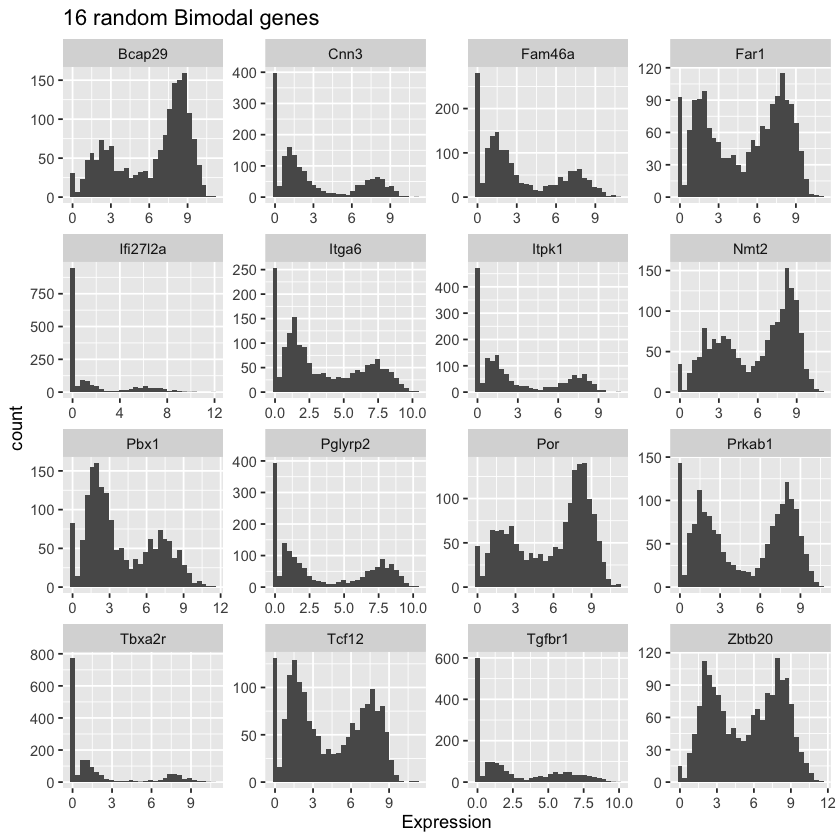

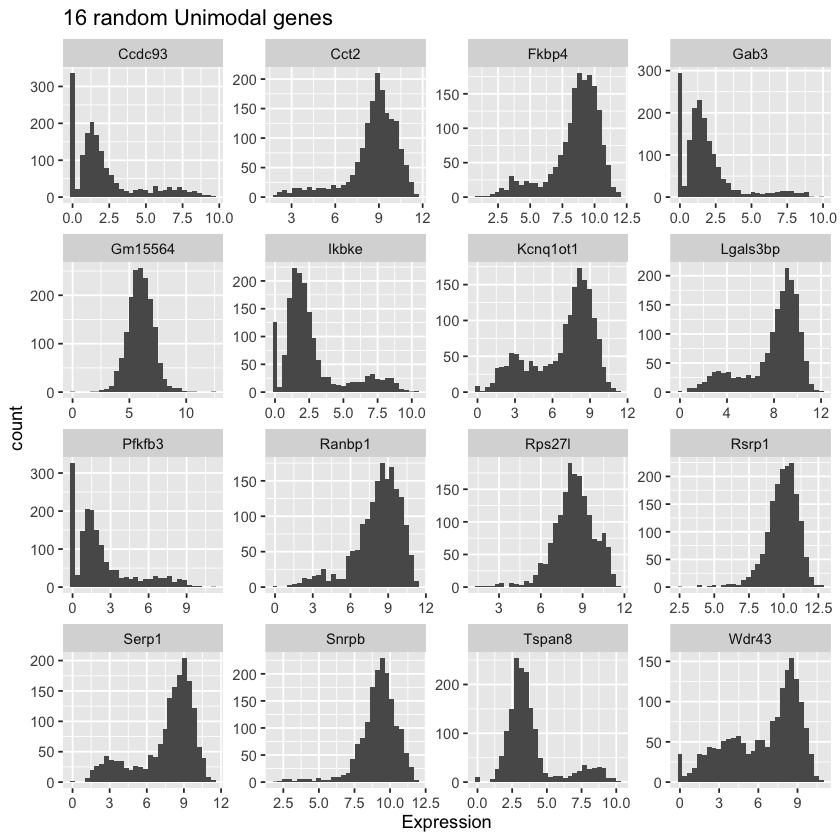

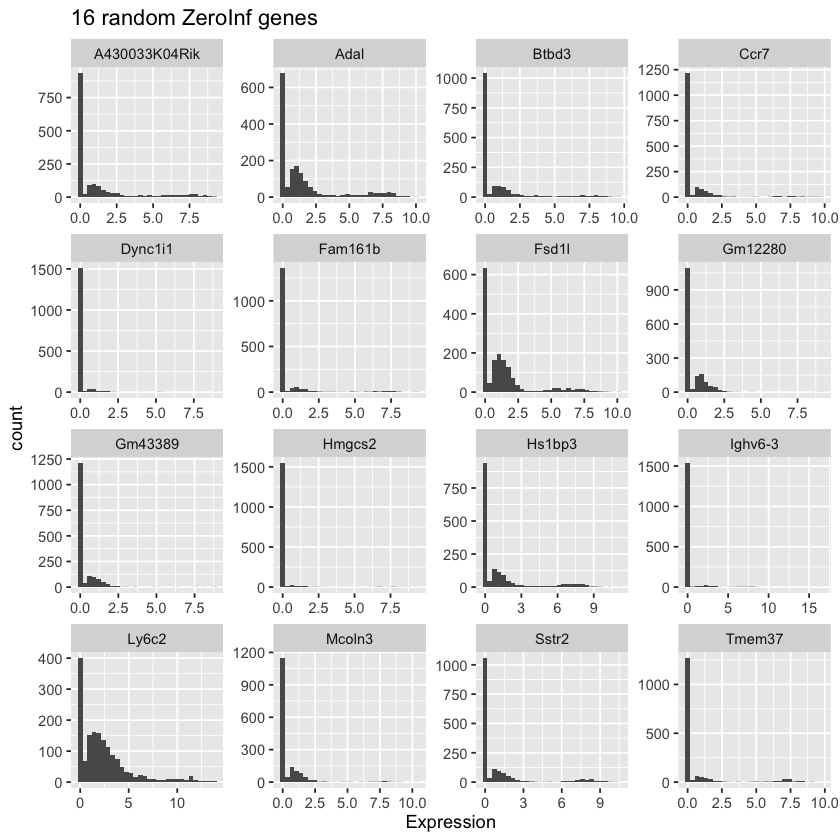

In [43]:
# ============================================================
# RANDOM EXAMPLES OF EACH CATEGORY
# ============================================================

plot_category <- function(category, n = 16) {

  genes <- criteria_Nestorowa %>%
    filter(Category == category) %>%
    pull(Gene)

  n_plot <- min(n, length(genes))

  if (n_plot == 0) {
    message("No genes in category: ", category)
    return(NULL)
  }

  selected_genes <- sample(genes, n_plot)

  Nestorowa_RNA %>%
    select(all_of(selected_genes)) %>%
    pivot_longer(
      cols = everything(),
      names_to = "Gene",
      values_to = "Expression"
    ) %>%
    ggplot(aes(x = Expression)) +
    geom_histogram(bins = 30) +
    facet_wrap(~Gene, scales = "free") +
    ggtitle(
      paste(
        n_plot,
        "random",
        category,
        "genes"
      )
    )
}


plot_category("Bimodal")
plot_category("Unimodal")
plot_category("ZeroInf")

Binarize data now that we have the functions and categories of gene activation

In [50]:
Nestorowa_RNA_prof <- binarize_exp(
  Nestorowa_RNA,
  Nestorowa_RNA,
  criteria_Nestorowa
)

head(Nestorowa_RNA_prof[, 1:19])

,Clec1b,Kdm3a,Coro2b,8430408G22Rik,Clec9a,Phf6,Usp14,Tmem167b,Kbtbd7,Rag2,Hmgcs1,Adgre1,Zfp947,Atad2,Bhlhb9,Vcam1,Mns1,Tbc1d5,Sardh
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,NA,1,NA,NA,NA,0,0,1,NA,NA,1,1,NA,0,1,NA,0,1,NA
2,NA,1,NA,NA,NA,0,0,0,NA,NA,0,NA,NA,0,0,NA,0,1,NA
3,NA,0,1,NA,NA,0,1,0,NA,NA,1,NA,NA,0,0,NA,0,0,NA
4,NA,0,1,NA,NA,1,0,0,NA,NA,1,NA,NA,0,1,1,0,0,NA
5,NA,0,1,NA,NA,1,0,0,1,NA,0,NA,NA,0,1,NA,0,1,NA
6,1,1,NA,NA,NA,1,0,0,1,NA,1,NA,NA,0,1,NA,0,0,NA


Check how much was successfully binarized

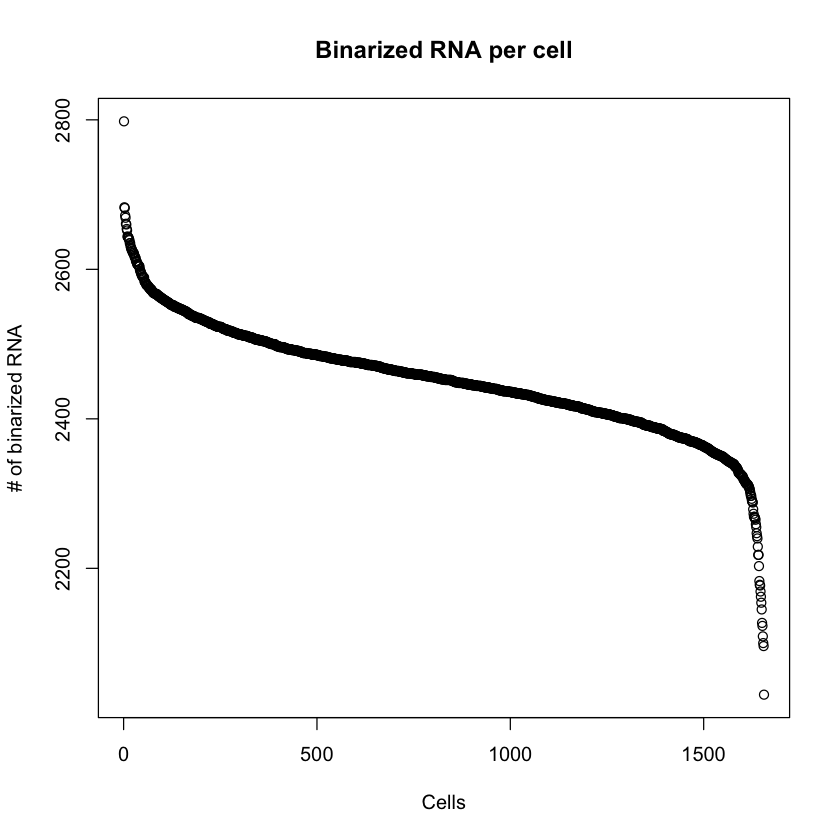

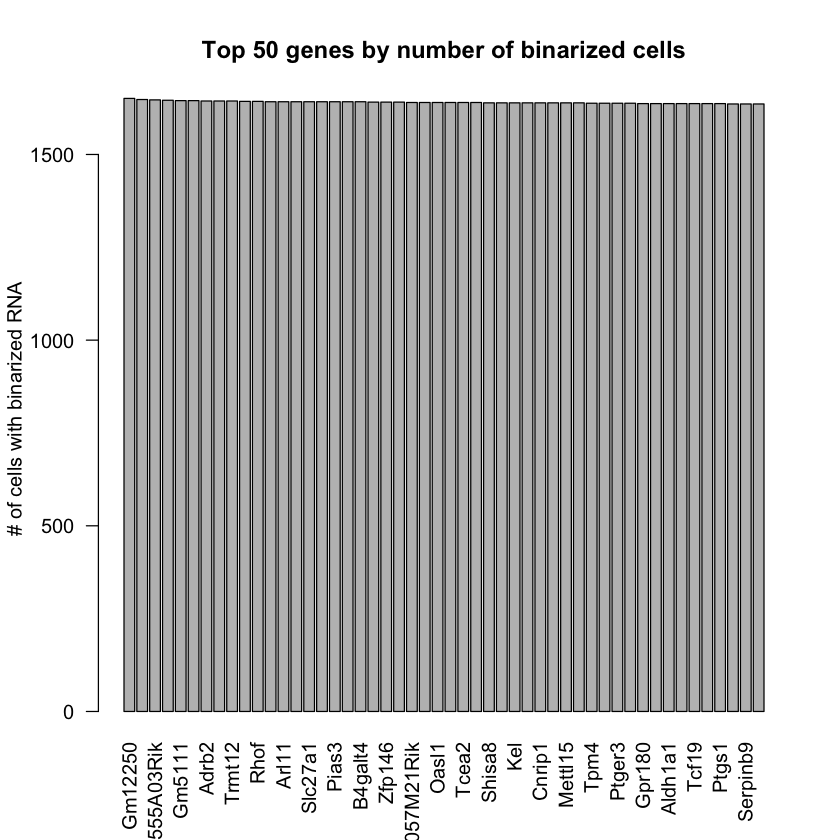

In [49]:
# Number of non-NA binary values per cell
Nestorowa_RNA_prof %>%
  select(-PATIENT_ID) %>%
  is.na() %>%
  `!` %>%
  rowSums() %>%
  sort(decreasing = TRUE) %>%
  plot(
    ylab = "# of binarized RNA",
    xlab = "Cells",
    main = "Binarized RNA per cell"
  )

#per gene:
Nestorowa_RNA_prof %>%
  select(-PATIENT_ID) %>%
  is.na() %>%
  `!` %>%
  colSums() %>%
  sort(decreasing = TRUE) %>%
  head(50) %>%
  barplot(
    las = 2,
    ylab = "# of cells with binarized RNA",
    main = "Top 50 genes by number of binarized cells"
  )

Get the correct file type out of this and save it as a tsv of the binarized RNA-seq data

In [55]:
# Remove PATIENT_ID
binary_matrix <- Nestorowa_RNA_prof %>%
  select(-PATIENT_ID)

write.csv(
  binary_matrix,
  file = "/Users/alicedecugis/Desktop/hematopoiesis/data/reproducing_results/nestorowa_binary_profiles.csv",
  quote = FALSE,
  row.names = TRUE,
  na = "NA"
)